# K-Map Practice

Exploring K-maps on binary images and PGS microstructures.

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

sys.path.insert(0, '.')
from pgs_tools import make_gaussian_fields, make_lithotype_map


## 1. Helper Functions

Three reusable functions used throughout the notebook.

In [3]:
def build_kmap(src, tgt, key_fn):
    """Learn a K-map: key_fn(src, r, c) -> pattern tuple, tgt[r,c] -> output.
    Returns dict: pattern -> [count_F0, count_F1]
    """
    kmap = defaultdict(lambda: [0, 0])
    for r in range(src.shape[0]):
        for c in range(src.shape[1]):
            key = key_fn(src, r, c)
            if key is not None:
                kmap[key][int(tgt[r, c])] += 1
    return kmap


def reconstruct(src, kmap, key_fn, border_fill=None):
    """Apply a learned K-map to src. Border pixels use border_fill if provided."""
    out = np.zeros_like(src)
    for r in range(src.shape[0]):
        for c in range(src.shape[1]):
            key = key_fn(src, r, c)
            if key is None:
                out[r, c] = border_fill[r, c] if border_fill is not None else 0
            else:
                c0, c1 = kmap[key]
                out[r, c] = 1 if c1 > c0 else 0
    return out


def accuracy(pred, target, border=1):
    """Pixel accuracy, ignoring the outermost border ring."""
    p, t = pred[border:-border, border:-border], target[border:-border, border:-border]
    m = np.sum(p == t)
    return m, p.size, 100 * m / p.size


# --- Neighbourhood key functions ---

def diag_key(grid, r, c):
    """Centre + 4 diagonal neighbours (5-bit key, 32 possible patterns)."""
    if r == 0 or r == grid.shape[0]-1 or c == 0 or c == grid.shape[1]-1:
        return None
    return (grid[r, c], grid[r-1, c-1], grid[r-1, c+1], grid[r+1, c-1], grid[r+1, c+1])


def full3x3_key(grid, r, c):
    """Full 3x3 neighbourhood (9-bit key, 512 possible patterns)."""
    if r == 0 or r == grid.shape[0]-1 or c == 0 or c == grid.shape[1]-1:
        return None
    return (
        grid[r-1, c-1], grid[r-1, c], grid[r-1, c+1],
        grid[r,   c-1], grid[r,   c], grid[r,   c+1],
        grid[r+1, c-1], grid[r+1, c], grid[r+1, c+1],
    )


print('Helpers loaded.')

Helpers loaded.


## 2. Boolean K-map

Classic 3-variable K-map. Finds the minimal boolean expression for a truth table.

In [4]:
AB = ['00', '01', '11', '10']
C  = ['0', '1']

F = [
    [1, 1],   # AB=00
    [1, 1],   # AB=01
    [0, 0],   # AB=11
    [0, 0],   # AB=10
]

ones = [ab + c for i, ab in enumerate(AB) for j, c in enumerate(C) if F[i][j] == 1]

expression = []
for idx, name in enumerate(['A', 'B', 'C']):
    bits = [cell[idx] for cell in ones]
    if all(b == '1' for b in bits):   expression.append(name)
    elif all(b == '0' for b in bits): expression.append(name + "'")

print('F =', ' '.join(expression))

# verify
ok = all(
    int(int(ab[0]) == 0) == F[i][j]
    for i, ab in enumerate(AB)
    for j, c in enumerate(C)
)
print('Verification:', '✓ all correct' if ok else '✗ errors found')

F = A'
Verification: ✓ all correct


## 3. Generate PGS Images

Two binary microstructures from the same Gaussian fields with different threshold splits.
These are used in all sections below.

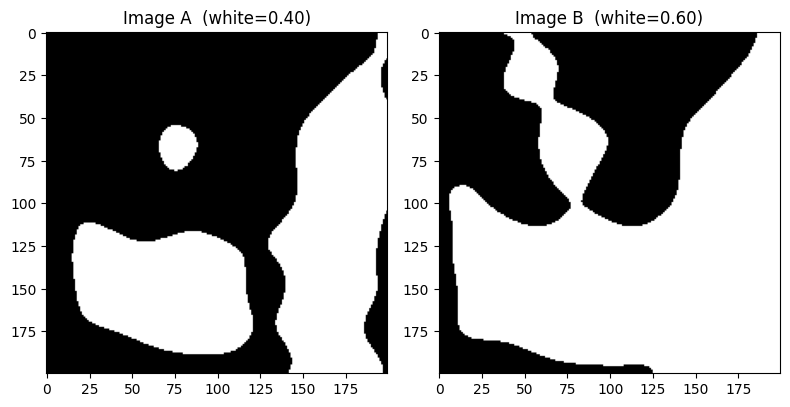

In [5]:
field_1, field_2 = make_gaussian_fields(grid_size=200, seed_1=0, seed_2=1)

# image A: 60% Mat1 (black), 40% Mat2 (white)
image_a = (make_lithotype_map(field_1, field_2, Mat1=0.6, Mat2=0.4, Mat3=0.0) > 0).astype(int)
# image B: 40% Mat1 (black), 60% Mat2 (white) — same fields, shifted threshold
image_b = (make_lithotype_map(field_1, field_2, Mat1=0.4, Mat2=0.6, Mat3=0.0) > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_a, cmap='gray'); axes[0].set_title(f'Image A  (white={image_a.mean():.2f})')
axes[1].imshow(image_b, cmap='gray'); axes[1].set_title(f'Image B  (white={image_b.mean():.2f})')
plt.tight_layout()
plt.show()

## 4. Single-Image K-map (Self-consistency)

Build a K-map from image A to itself: diagonal neighbourhood → centre pixel.
Then apply it back to check how well local context predicts each pixel.

In [16]:
kmap_self = build_kmap(image_a, image_a, diag_key)

print(f'Unique patterns seen: {len(kmap_self)} / 32 possible')
print()
print('(ctr, TL, TR, BL, BR) | F=0    F=1   | majority')
print('-' * 52)
for key in sorted(kmap_self.keys()):
    c0, c1 = kmap_self[key]
    k = tuple(int(x) for x in key)
    print(f'  {k}  | {c0:5d}  {c1:5d} | {1 if c1 > c0 else 0}')

Unique patterns seen: 19 / 32 possible

(ctr, TL, TR, BL, BR) | F=0    F=1   | majority
----------------------------------------------------
  (0, 0, 0, 0, 0)  | 22424      0 | 0
  (0, 0, 0, 0, 1)  |   184      0 | 0
  (0, 0, 0, 1, 0)  |   108      0 | 0
  (0, 0, 0, 1, 1)  |    72      0 | 0
  (0, 0, 1, 0, 0)  |   120      0 | 0
  (0, 0, 1, 0, 1)  |   158      0 | 0
  (0, 1, 0, 0, 0)  |    76      0 | 0
  (0, 1, 0, 1, 0)  |   134      0 | 0
  (0, 1, 1, 0, 0)  |    69      0 | 0
  (1, 0, 0, 1, 1)  |     0     76 | 1
  (1, 0, 1, 0, 1)  |     0    162 | 1
  (1, 0, 1, 1, 1)  |     0    176 | 1
  (1, 1, 0, 0, 0)  |     0      1 | 1
  (1, 1, 0, 1, 0)  |     0    135 | 1
  (1, 1, 0, 1, 1)  |     0    104 | 1
  (1, 1, 1, 0, 0)  |     0     72 | 1
  (1, 1, 1, 0, 1)  |     0    112 | 1
  (1, 1, 1, 1, 0)  |     0     77 | 1
  (1, 1, 1, 1, 1)  |     0  14944 | 1


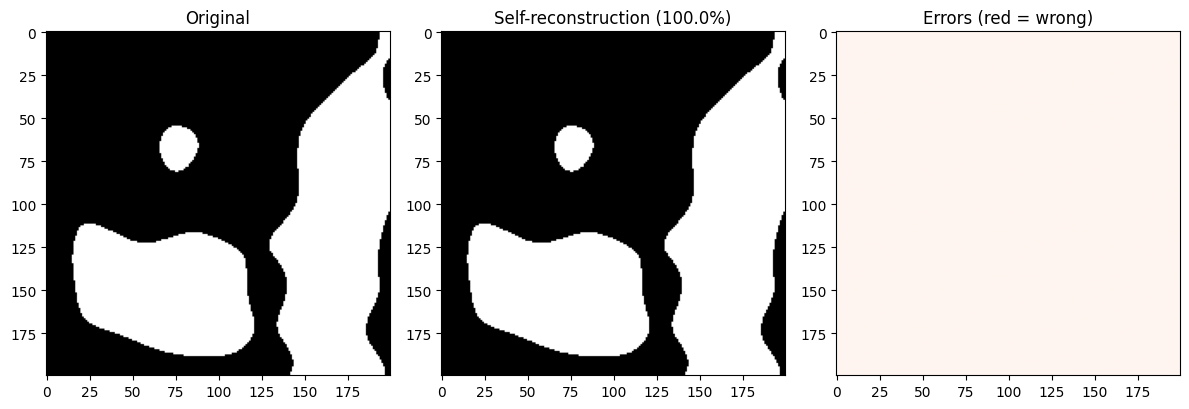

Accuracy: 39204/39204 (100.0%)  — errors are at phase boundaries.


In [7]:
recon_self = reconstruct(image_a, kmap_self, diag_key, border_fill=image_a)
m, t, pct  = accuracy(recon_self, image_a)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_a,              cmap='gray', vmin=0, vmax=1); axes[0].set_title('Original')
axes[1].imshow(recon_self,           cmap='gray', vmin=0, vmax=1); axes[1].set_title(f'Self-reconstruction ({pct:.1f}%)')
axes[2].imshow(image_a != recon_self, cmap='Reds', vmin=0, vmax=1); axes[2].set_title('Errors (red = wrong)')
plt.tight_layout()
plt.show()
print(f'Accuracy: {m}/{t} ({pct:.1f}%)  — errors are at phase boundaries.')

## 5. Two-Image K-map: A → B

Learn a K-map from image A and apply it to reconstruct image B.
~83% is the expected ceiling — pixels deep inside a phase are easy;
boundary pixels are ambiguous because the same local pattern can map to either value.

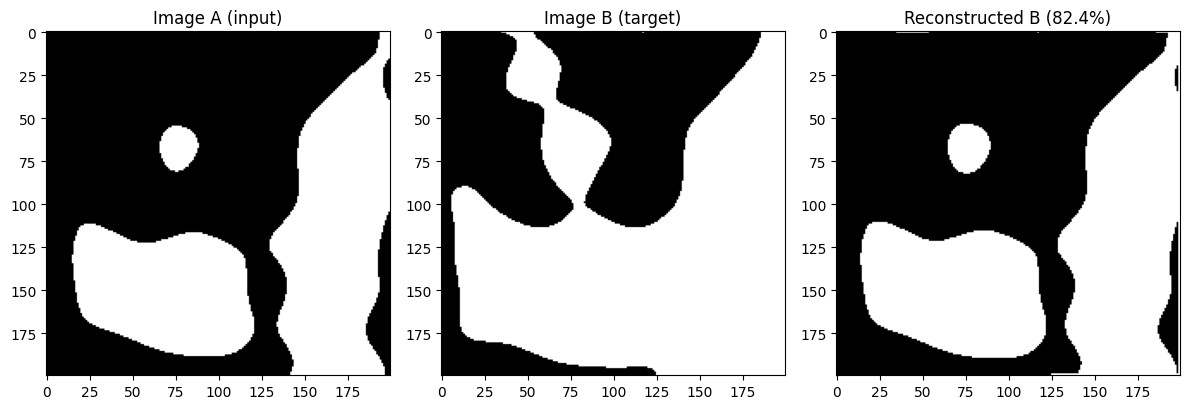

Accuracy: 32291/39204 (82.4%)


In [8]:
kmap_ab  = build_kmap(image_a, image_b, full3x3_key)
recon_ab = reconstruct(image_a, kmap_ab, full3x3_key, border_fill=image_b)
m, t, pct = accuracy(recon_ab, image_b)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_a,  cmap='gray'); axes[0].set_title('Image A (input)')
axes[1].imshow(image_b,  cmap='gray'); axes[1].set_title('Image B (target)')
axes[2].imshow(recon_ab, cmap='gray'); axes[2].set_title(f'Reconstructed B ({pct:.1f}%)')
plt.tight_layout()
plt.show()
print(f'Accuracy: {m}/{t} ({pct:.1f}%)')

## 6. Difference K-map

Instead of mapping A→B directly, look at what *changed*.
`diff = B - A` marks pixels that flipped: +1 = gained white, -1 = lost white.
Then ask: for each pixel in A, how many white neighbours does it have,
and what fraction of pixels with that count actually flipped?
This is split into gains (black→white) and losses (white→black) to show asymmetry.

Unchanged:  80.0%
Gained 0→1: 20.0%
Lost   1→0: 0.0%


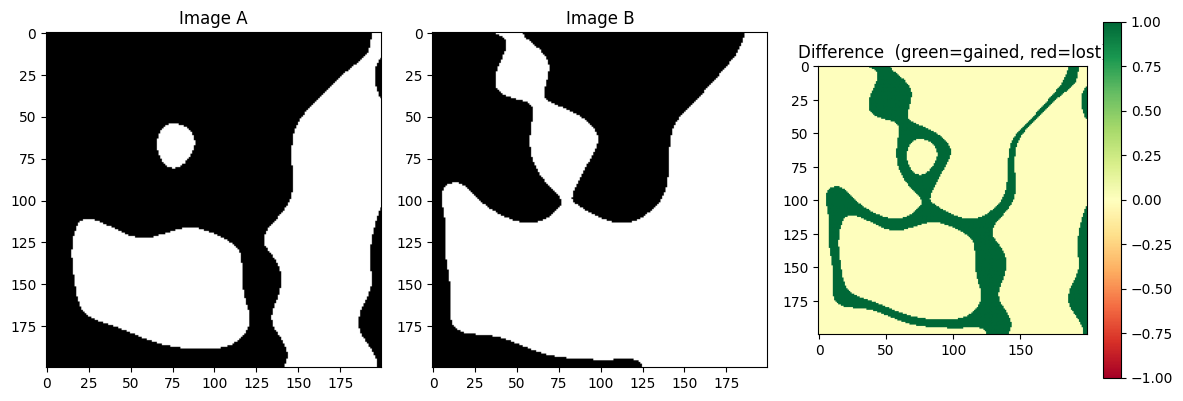

In [9]:
diff = image_b.astype(int) - image_a.astype(int)

print(f'Unchanged:  {np.mean(diff == 0)*100:.1f}%')
print(f'Gained 0→1: {np.mean(diff == 1)*100:.1f}%')
print(f'Lost   1→0: {np.mean(diff ==-1)*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_a, cmap='gray'); axes[0].set_title('Image A')
axes[1].imshow(image_b, cmap='gray'); axes[1].set_title('Image B')
im = axes[2].imshow(diff, cmap='RdYlGn', vmin=-1, vmax=1)
axes[2].set_title('Difference  (green=gained, red=lost)')
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

In [10]:
rows, cols = image_a.shape
gain_by_n = defaultdict(lambda: [0, 0])   # black pixels: [stayed_black, became_white]
loss_by_n = defaultdict(lambda: [0, 0])   # white pixels: [stayed_white, became_black]

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        n_white = int(
            image_a[r-1,c-1] + image_a[r-1,c] + image_a[r-1,c+1] +
            image_a[r,  c-1]                   + image_a[r,  c+1] +
            image_a[r+1,c-1] + image_a[r+1,c]  + image_a[r+1,c+1]
        )
        if image_a[r, c] == 0:
            gain_by_n[n_white][int(diff[r, c] == 1)] += 1
        else:
            loss_by_n[n_white][int(diff[r, c] == -1)] += 1

print(f'Total gained: {int(np.sum(diff==1))}   Total lost: {int(np.sum(diff==-1))}')
print()
print('Nbrs | Gain prob (black→white)        | Loss prob (white→black)')
print('-' * 68)
for n in range(9):
    gs, gf = gain_by_n[n];  g = gf/(gs+gf) if (gs+gf) > 0 else None
    ls, lf = loss_by_n[n];  l = lf/(ls+lf) if (ls+lf) > 0 else None
    g_str = f'{g:.3f} {"█"*int(g*15)}' if g is not None else '  —'
    l_str = f'{l:.3f} {"█"*int(l*15)}' if l is not None else '  —'
    if (gs+gf) > 0 or (ls+lf) > 0:
        print(f'  {n}  | {g_str:<32s} | {l_str}')

Total gained: 8000   Total lost: 0

Nbrs | Gain prob (black→white)        | Loss prob (white→black)
--------------------------------------------------------------------
  0  | 0.308 ████                       |   —
  1  | 1.000 ███████████████            |   —
  2  | 1.000 ███████████████            |   —
  3  | 1.000 ███████████████            | 0.000 
  4  | 1.000 ███████████████            | 0.000 
  5  |   —                              | 0.000 
  6  |   —                              | 0.000 
  7  |   —                              | 0.000 
  8  |   —                              | 0.000 


## 7. Probabilistic K-map

Instead of a majority vote, output the probability p = count_1 / (count_0 + count_1).
The result is a greyscale confidence map — pixels near 0 or 1 are certain,
pixels near 0.5 are ambiguous boundary pixels.

Confident pixels (p < 0.3 or p > 0.7): 17576  (43.9%)
Uncertain pixels (0.3 < p < 0.7):       22424  (56.1%)


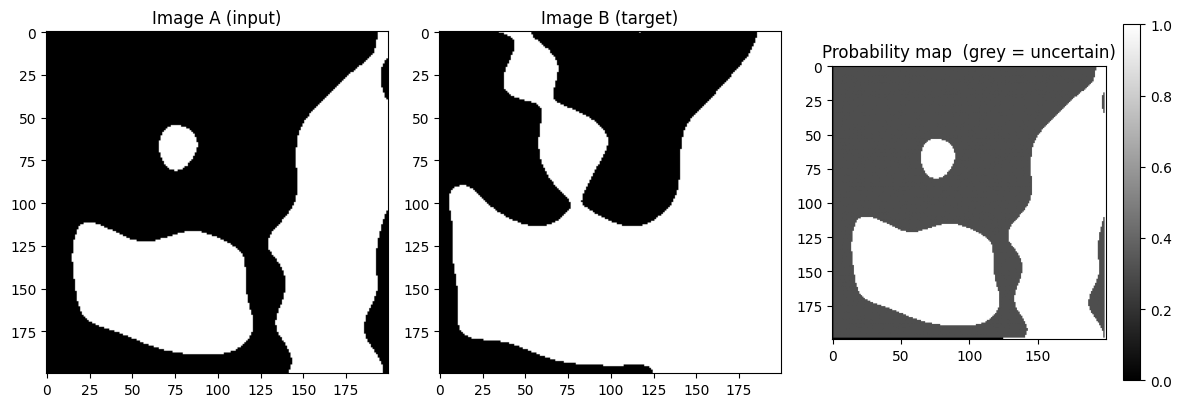

In [11]:
# build probabilistic K-map
counts = defaultdict(lambda: [0, 0])
for r in range(image_a.shape[0]):
    for c in range(image_a.shape[1]):
        key = full3x3_key(image_a, r, c)
        if key is not None:
            counts[key][int(image_b[r, c])] += 1

prob_kmap = {k: v[1] / (v[0] + v[1]) for k, v in counts.items()}

# apply to get probability map
prob_map = np.zeros(image_a.shape, dtype=float)
for r in range(image_a.shape[0]):
    for c in range(image_a.shape[1]):
        key = full3x3_key(image_a, r, c)
        prob_map[r, c] = prob_kmap.get(key, float(image_b[r, c]))

uncertain = np.sum((prob_map > 0.3) & (prob_map < 0.7))
print(f'Confident pixels (p < 0.3 or p > 0.7): {prob_map.size - uncertain}  ({100*(prob_map.size-uncertain)/prob_map.size:.1f}%)')
print(f'Uncertain pixels (0.3 < p < 0.7):       {uncertain}  ({100*uncertain/prob_map.size:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_a,  cmap='gray', vmin=0, vmax=1); axes[0].set_title('Image A (input)')
axes[1].imshow(image_b,  cmap='gray', vmin=0, vmax=1); axes[1].set_title('Image B (target)')
im = axes[2].imshow(prob_map, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Probability map  (grey = uncertain)')
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

## Summary

**What we found:**

- **Self-consistency (Section 4):** ~100% accuracy. The K-map perfectly recovers image A from itself because every pattern has one consistent answer.
- **A→B reconstruction (Section 5):** ~83% accuracy. Interior pixels are easy; boundary pixels are ambiguous because the same local pattern appears on both sides of the shifted threshold.
- **Difference K-map (Section 6):** flip probability is almost entirely determined by neighbour count. Pixels with 1–3 white neighbours flip with near certainty; interior pixels rarely flip.
- **Probabilistic K-map (Section 7):** ~57% of pixels are uncertain (p between 0.3 and 0.7) — these are the boundary pixels the binary K-map gets wrong.

**Why reconstruction fails for PGS threshold shifts:**
Whether a boundary pixel flips depends on its underlying continuous Gaussian value, which the binary K-map cannot see. This is not a bug — it is the fundamental limit of local binary rules for global threshold changes.

**Useful applications going forward:**
- K-map fingerprint (pattern frequency distribution) as a distance metric between microstructures — inverse problem direction.
- Difference K-map to characterise what local conditions drive phase changes under a CA rule.

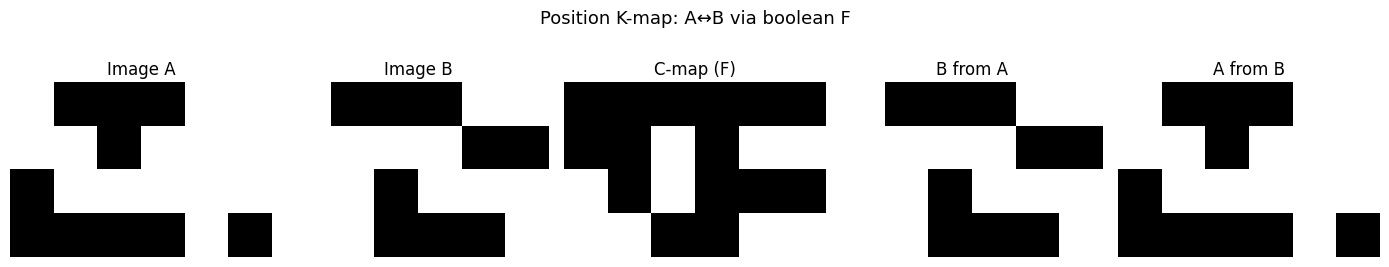

A → B correct: True
B → A correct: True


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ── Images ──────────────────────────────────────────────────────────────────
img_A = np.array([
    [1,0,0,0,1,1],
    [1,1,0,1,1,1],
    [0,1,1,1,1,1],
    [0,0,0,0,1,0]
])

img_B = np.array([
    [1,0,0,0,1,1],
    [1,1,1,1,0,0],
    [1,1,0,1,1,1],
    [1,1,0,0,0,1]
])

# ── C-map (change map) ───────────────────────────────────────────────────────
C_map = (img_A != img_B).astype(int)

# ── Gray code lookup ─────────────────────────────────────────────────────────
row_gray = {0: (0,0), 1: (0,1), 2: (1,1), 3: (1,0)}
col_gray = {0: (0,0,0), 1: (0,0,1), 2: (0,1,1), 3: (0,1,0),
            4: (1,1,0), 5: (1,1,1)}

# ── Boolean function F = A'BCD + AB'CD + AD'E' + AB'D' + BC'DE ──────────────
def F(A, B, C, D, E):
    t1 = (1-A)*B*C*D          # A'BCD
    t2 = A*(1-B)*C*D          # AB'CD
    t3 = A*(1-D)*(1-E)        # AD'E'
    t4 = A*(1-B)*(1-D)        # AB'D'
    t5 = B*(1-C)*D*E          # BC'DE
    return int(t1 or t2 or t3 or t4 or t5)

# Build the flip map from F
flip_map = np.zeros_like(img_A)
for r in range(img_A.shape[0]):
    for c in range(img_A.shape[1]):
        Ab, Bb = row_gray[r]
        Cb, Db, Eb = col_gray[c]
        flip_map[r, c] = F(Ab, Bb, Cb, Db, Eb)

# ── Reconstruct ──────────────────────────────────────────────────────────────
# A + F → B    (XOR flips where F=1)
B_from_A = img_A ^ flip_map

# B + F → A    (XOR is self-inverse)
A_from_B = img_B ^ flip_map

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
titles = ['Image A', 'Image B', 'C-map (F)', 'B from A', 'A from B']
imgs   = [img_A, img_B, flip_map, B_from_A, A_from_B]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Position K-map: A↔B via boolean F', fontsize=13)
plt.tight_layout()
plt.show()

print("A → B correct:", np.array_equal(B_from_A, img_B))
print("B → A correct:", np.array_equal(A_from_B, img_A))

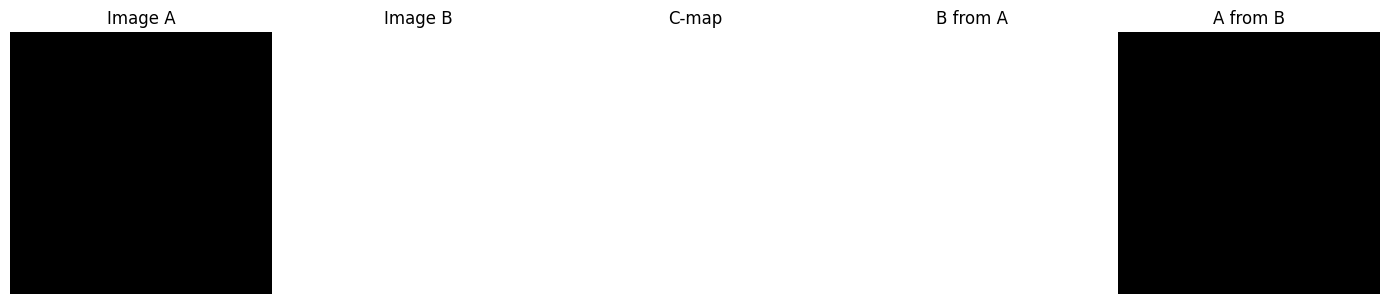

A→B correct: True
B→A correct: True


In [26]:
import numpy as np
import matplotlib.pyplot as plt

A = np.zeros((8, 8), dtype=int)
B = np.ones((8, 8),  dtype=int)

C_map = (A != B).astype(int)

B_from_A = A ^ C_map
A_from_B = B ^ C_map

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, img, title in zip(axes, [A, B, C_map, B_from_A, A_from_B],
                                 ['Image A', 'Image B', 'C-map', 'B from A', 'A from B']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("A→B correct:", np.array_equal(B_from_A, B))
print("B→A correct:", np.array_equal(A_from_B, A))

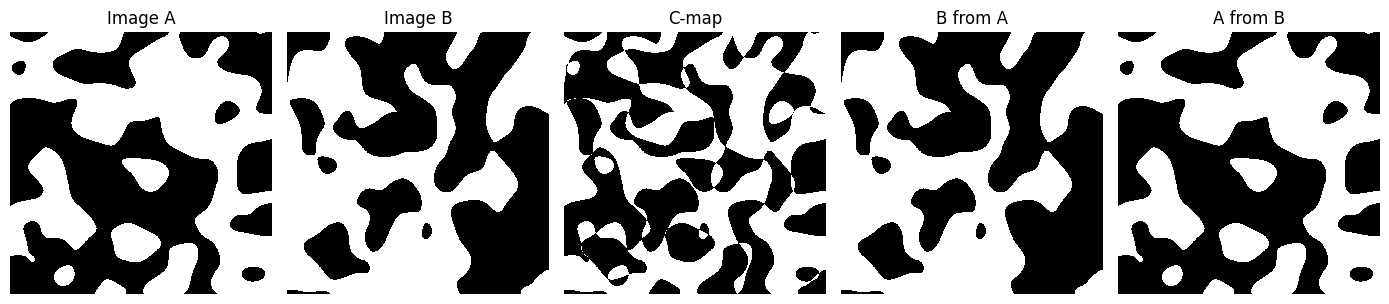

A→B correct: True
B→A correct: True
Sum A - A_reconstructed: 0
Sum B - B_reconstructed: 0


In [42]:

import numpy as np
import matplotlib.pyplot as plt
from pgs_tools import make_gaussian_fields, make_lithotype_map

# Generate two PGS lithotype maps — Mat1=0 makes them binary (phases 1 and 2 only)
f1a, f2a = make_gaussian_fields(grid_size=1024, seed_1=0, seed_2=1, len_scale_1=[80,80], len_scale_2=[80,80])
f1b, f2b = make_gaussian_fields(grid_size=1024, seed_1=5, seed_2=6, len_scale_1=[80,80], len_scale_2=[80,80])

litho_A = make_lithotype_map(f1a, f2a, Mat1=0, Mat2=0.5, Mat3=0.5)
litho_B = make_lithotype_map(f1b, f2b, Mat1=0, Mat2=0.5, Mat3=0.5)

# Convert to binary (phase 2 → 1, phase 1 → 0)
A = (litho_A == 2).astype(int)
B = (litho_B == 2).astype(int)

# C-map and reconstruction
C_map  = (A != B).astype(int)
B_from_A = A ^ C_map
A_from_B = B ^ C_map

# Plot
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, img, title in zip(axes, [A, B, C_map, B_from_A, A_from_B],
                                 ['Image A', 'Image B', 'C-map', 'B from A', 'A from B']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("A→B correct:", np.array_equal(B_from_A, B))
print("B→A correct:", np.array_equal(A_from_B, A))

diff_A = A - A_from_B
diff_B = B - B_from_A

print("Sum A - A_reconstructed:", diff_A.sum())
print("Sum B - B_reconstructed:", diff_B.sum())